In [5]:
from torchvision.datasets.imagenette import Imagenette
from torch.utils.data.dataloader import DataLoader
import torch
import timm


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

dinov3 = timm.create_model("vit_base_patch16_dinov3.lvd1689m", pretrained=True).to(
    device
)
dinov3.eval()
data_config = timm.data.resolve_model_data_config(dinov3)
dino_transforms = timm.data.create_transform(**data_config, is_training=False)

val_data = Imagenette("./data", split="val", download=True, transform=dino_transforms)
val_loader = DataLoader(val_data, batch_size=256, shuffle=True)

images = next(iter(val_loader))[0].to(device)
with torch.no_grad():
    val_activations = dinov3.forward_features(images.to(device))[:, 5:]

n, p, d = val_activations.shape
val_activations = val_activations.reshape(n * p, d)
print(n, p, d)

256 256 768


Concept 27


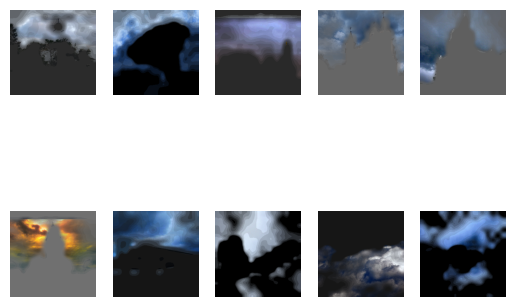

Concept 40


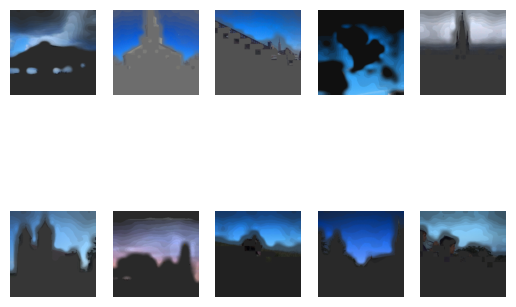

Concept 3


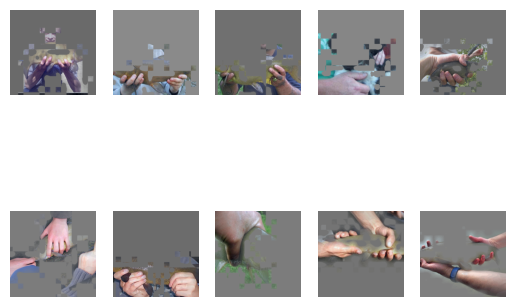

Concept 9


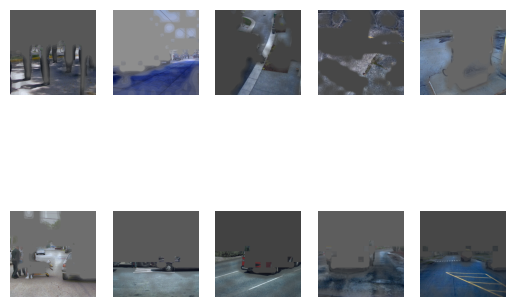

Concept 32


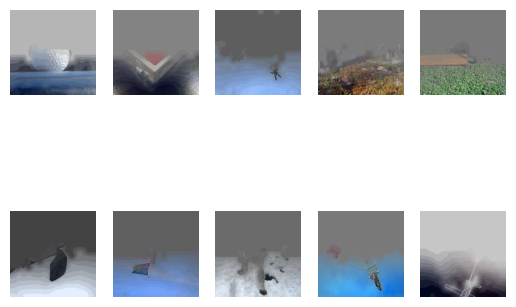

Concept 38


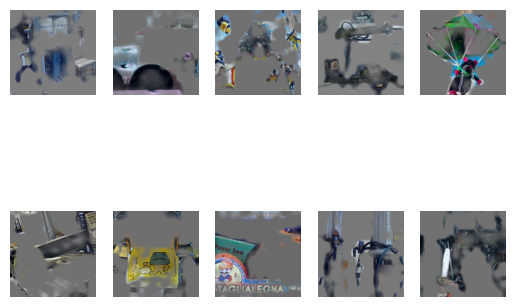

Concept 5


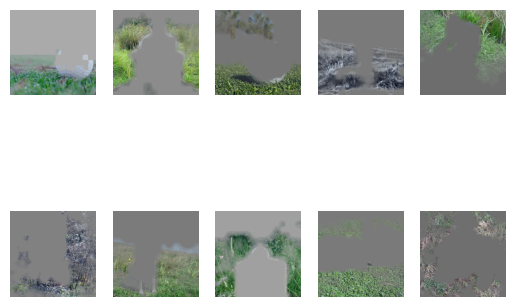

In [ ]:
from overcomplete.sae import TopKSAE
from overcomplete.visualization import (
    overlay_top_heatmaps,
    contour_top_image,
    evidence_top_images,
)
import matplotlib.pyplot as plt

n_concepts = 50
sae = TopKSAE(768, n_concepts, 5, device=device)
sae.load_state_dict(torch.load("SAE_d50_k5_topk_auxillary_loss_with_wica_report.pth"))
sae.eval()

with torch.no_grad():
    pre_codes, codes = sae.encode(val_activations)

codes = codes.view(n, 16, 16, n_concepts)

for i in [30, 4, 32, 34, 38, 36, 22, 14]:
    print("Concept", i)
    evidence_top_images(images, codes, concept_id=i)
    plt.show()